In [1]:
pwd

'/data1/kishoretarafdar/src2D/GIIR'

In [1]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

from TFDWT.DWT1DFB import DWT1D, IDWT1D
from TFDWT.DWT2DFB import DWT2D, IDWT2D
import matplotlib.pyplot as plt

2025-07-01 02:47:06.048106: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751318226.069374 3544438 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751318226.075926 3544438 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-01 02:47:06.098548: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version 2.18.0
Num GPUs Available:  3


I0000 00:00:1751318228.273585 3544438 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


In [2]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
x = tf.constant([1.,7.,11.,13., 17., 19.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
# x = tf.constant([1.,2], dtype=tf.float32)




# x = [0,0,0,0,1,1,1,1]
wave = 'haar'
# wave = 'db2'
# wave = 'db3'

## filter init
# h = tf.constant([1,2,3,5], dtype=tf.float32)
# h = tf.constant([1,2,3,4], dtype=tf.float32)
# h = tf.constant([1,1,1,1], dtype=tf.float32)
h = tf.constant([1,2], dtype=tf.float32)

# h = tf.constant([1.,5.], dtype=tf.float32)
# h = tf.constant([1,0,0,0], dtype=tf.float32)
## Matching filter size with input size with zero padding
L = h.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
        ]
h_padded = tf.pad(h, paddings, mode='CONSTANT', constant_values=0)
h_padded.shape


## Creating x[n-k] for all n
N = Npoint
n = tf.range(N)
row_indices = tf.math.mod(n[:, tf.newaxis]-n, N)
print(row_indices)
h_rows_shifted = tf.gather(h_padded, row_indices, axis=0)
print(x.shape, h_padded.shape, h_rows_shifted.shape), 
x, h_padded, h_rows_shifted

tf.Tensor(
[[0 5 4 3 2 1]
 [1 0 5 4 3 2]
 [2 1 0 5 4 3]
 [3 2 1 0 5 4]
 [4 3 2 1 0 5]
 [5 4 3 2 1 0]], shape=(6, 6), dtype=int32)
(6,) (6,) (6, 6)


(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 1.,  7., 11., 13., 17., 19.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([1., 2., 0., 0., 0., 0.], dtype=float32)>,
 <tf.Tensor: shape=(6, 6), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 2.],
        [2., 1., 0., 0., 0., 0.],
        [0., 2., 1., 0., 0., 0.],
        [0., 0., 2., 1., 0., 0.],
        [0., 0., 0., 2., 1., 0.],
        [0., 0., 0., 0., 2., 1.]], dtype=float32)>)

In [3]:
h_rows_shifted[1,:] * x

<tf.Tensor: shape=(6,), dtype=float32, numpy=array([2., 7., 0., 0., 0., 0.], dtype=float32)>

In [4]:
# tf.reverse(tf.reverse(tf.math.mod(n[:, tf.newaxis] - n, N), axis=[0]), axis=[-1])

        True value

In [5]:
print(x.shape, h_rows_shifted.shape)
y1n = tf.einsum('ij,j->i', h_rows_shifted, x)
y1n

(6,) (6, 6)


<tf.Tensor: shape=(6,), dtype=float32, numpy=array([39.,  9., 25., 35., 43., 53.], dtype=float32)>

In [6]:
# res = []
# for r in range(x.shape[0]):
#     res.append(tf.reduce_sum(x * h_rows_shifted[r,:]))
# y1n = tf.stack(res,axis=-1)
# y1n
# ## OK

In [7]:
DWT1D(wave, clean=False)(tf.expand_dims(tf.expand_dims(y1n, axis=0), axis=-1))

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[33.941124],
        [42.426407],
        [67.88225 ],
        [21.213203],
        [-7.071068],
        [-7.071067]]], dtype=float32)>

---

In [8]:
#rough
hshifted = h_rows_shifted
h.numpy(), hshifted.numpy(), hshifted[0,:].numpy(), hshifted[1,:].numpy(), x.numpy(), tf.reduce_sum(hshifted[1,:]*x).numpy() 
## OK  ## n-axis --->n

(array([1., 2.], dtype=float32),
 array([[1., 0., 0., 0., 0., 2.],
        [2., 1., 0., 0., 0., 0.],
        [0., 2., 1., 0., 0., 0.],
        [0., 0., 2., 1., 0., 0.],
        [0., 0., 0., 2., 1., 0.],
        [0., 0., 0., 0., 2., 1.]], dtype=float32),
 array([1., 0., 0., 0., 0., 2.], dtype=float32),
 array([2., 1., 0., 0., 0., 0.], dtype=float32),
 array([ 1.,  7., 11., 13., 17., 19.], dtype=float32),
 np.float32(9.0))

In [9]:
# hshifted = tf.reverse(hshifted, axis=[1,0])
# hshifted

In [10]:
tf.expand_dims(hshifted[0:1,:], axis=-1)

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [2.]]], dtype=float32)>

In [11]:
_ = tf.expand_dims(hshifted, axis=-1)
hinit = DWT1D(wave, clean=False)(_)
# del _
print(tf.squeeze(hinit)) # l-axis below --->l  and n-axis ^

# OK
_ = _[1:2,...]
print(tf.squeeze(_).numpy())
tf.squeeze(DWT1D(wave, clean=False)(_)).numpy() # 

tf.Tensor(
[[ 0.70710677  0.          1.4142135   0.70710677  0.         -1.4142135 ]
 [ 2.1213202   0.          0.          0.70710677  0.          0.        ]
 [ 1.4142135   0.70710677  0.         -1.4142135   0.70710677  0.        ]
 [ 0.          2.1213202   0.          0.          0.70710677  0.        ]
 [ 0.          1.4142135   0.70710677  0.         -1.4142135   0.70710677]
 [ 0.          0.          2.1213202   0.          0.          0.70710677]], shape=(6, 6), dtype=float32)
[2. 1. 0. 0. 0. 0.]


array([2.1213202 , 0.        , 0.        , 0.70710677, 0.        ,
       0.        ], dtype=float32)

In [12]:
# hinit = w_
# hinit.shape, tf.squeeze(hinit) # l-axis below --->l  and n-axis ^

In [13]:
hinitT = tf.transpose(hinit, perm=[1,0,2])
print(hinit.shape, '\n', tf.squeeze(hinitT).numpy()) # n-axis below --->n  and ^l

(6, 6, 1) 
 [[ 0.70710677  2.1213202   1.4142135   0.          0.          0.        ]
 [ 0.          0.          0.70710677  2.1213202   1.4142135   0.        ]
 [ 1.4142135   0.          0.          0.          0.70710677  2.1213202 ]
 [ 0.70710677  0.70710677 -1.4142135   0.          0.          0.        ]
 [ 0.          0.          0.70710677  0.70710677 -1.4142135   0.        ]
 [-1.4142135   0.          0.          0.          0.70710677  0.70710677]]


In [14]:
# H = IDWT1D(wave)(hinitT)
# H = DWT1D(wave)(H)

H = DWT1D(wave, clean=False)(hinitT)

print(tf.squeeze(hinitT).numpy(), '\n\n', tf.squeeze(H).numpy())

##OK
print('\n\n',tf.squeeze(hinitT[0:1,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[0:1,...])).numpy())
print('\n',tf.squeeze(hinitT[1:2,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[1:2,...])).numpy())
## v-axis below --->v and ^l

[[ 0.70710677  2.1213202   1.4142135   0.          0.          0.        ]
 [ 0.          0.          0.70710677  2.1213202   1.4142135   0.        ]
 [ 1.4142135   0.          0.          0.          0.70710677  2.1213202 ]
 [ 0.70710677  0.70710677 -1.4142135   0.          0.          0.        ]
 [ 0.          0.          0.70710677  0.70710677 -1.4142135   0.        ]
 [-1.4142135   0.          0.          0.          0.70710677  0.70710677]] 

 [[ 1.99999988e+00  9.99999940e-01  0.00000000e+00 -9.99999940e-01
   9.99999940e-01  0.00000000e+00]
 [ 0.00000000e+00  1.99999988e+00  9.99999940e-01  0.00000000e+00
  -9.99999940e-01  9.99999940e-01]
 [ 9.99999940e-01  0.00000000e+00  1.99999988e+00  9.99999940e-01
   0.00000000e+00 -9.99999940e-01]
 [ 9.99999940e-01 -9.99999940e-01  0.00000000e+00 -1.26880515e-08
  -9.99999940e-01  0.00000000e+00]
 [ 0.00000000e+00  9.99999940e-01 -9.99999940e-01  0.00000000e+00
  -1.26880515e-08 -9.99999940e-01]
 [-9.99999940e-01  0.00000000e+00  9.9999

In [15]:
HT = tf.transpose(H, perm=[1,0,2])
print(HT.shape, '\n', tf.squeeze(HT).numpy())   ## l-axis below --->l and ^v
# HT=H

(6, 6, 1) 
 [[ 1.99999988e+00  0.00000000e+00  9.99999940e-01  9.99999940e-01
   0.00000000e+00 -9.99999940e-01]
 [ 9.99999940e-01  1.99999988e+00  0.00000000e+00 -9.99999940e-01
   9.99999940e-01  0.00000000e+00]
 [ 0.00000000e+00  9.99999940e-01  1.99999988e+00  0.00000000e+00
  -9.99999940e-01  9.99999940e-01]
 [-9.99999940e-01  0.00000000e+00  9.99999940e-01 -1.26880515e-08
   0.00000000e+00 -9.99999940e-01]
 [ 9.99999940e-01 -9.99999940e-01  0.00000000e+00 -9.99999940e-01
  -1.26880515e-08  0.00000000e+00]
 [ 0.00000000e+00  9.99999940e-01 -9.99999940e-01  0.00000000e+00
  -9.99999940e-01 -1.26880515e-08]]


In [16]:
# HT = tf.expand_dims(tf.expand_dims(tf.constant([5.9999995, -3.9999998]), axis=-1), axis=0)
# HT

In [17]:
# HT = tf.expand_dims(tf.expand_dims(tf.constant([5.5, 2.4999998, 1.5000001, 1.5000001]), axis=-1), axis=0)
# HT

        H[v,l] 

In [18]:
_ = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
print('x:= ', _.shape, _[0,:,0].numpy())
α = DWT1D(wave, clean=False)(_)

# α = IDWT1D(wave)(_)
# α = IDWT1D(wave)(α)

print('α:= ', α.shape, tf.squeeze(α).numpy())

x:=  (1, 6, 1) [ 1.  7. 11. 13. 17. 19.]
α:=  (1, 6, 1) [ 5.656854  16.970562  25.455843  -4.2426405 -1.4142132 -1.4142137]


In [19]:
print('\n', HT[0,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[0,:,0] * α[0,:,0]).numpy())
print('\n', HT[1,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[1,:,0] * α[0,:,0]).numpy())
# print('\n', HT[2,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[2,:,0] * α[0,:,0]).numpy())
# print('\n', HT[3,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[3,:,0] * α[0,:,0]).numpy())
# 5.5 * 5.656854, 2.4999998*16.970562


 [ 1.9999999   0.          0.99999994  0.99999994  0.         -0.99999994] 
 [ 5.656854  16.970562  25.455843  -4.2426405 -1.4142132 -1.4142137] 
 [11.313707   0.        25.455841  -4.24264   -0.         1.4142135]

 [ 0.99999994  1.9999999   0.         -0.99999994  0.99999994  0.        ] 
 [ 5.656854  16.970562  25.455843  -4.2426405 -1.4142132 -1.4142137] 
 [ 5.6568537 33.94112    0.         4.24264   -1.4142131 -0.       ]


In [20]:
α[0,:,0]  * HT[0,:,0]

<tf.Tensor: shape=(6,), dtype=float32, numpy=
array([11.313707 ,  0.       , 25.455841 , -4.24264  , -0.       ,
        1.4142135], dtype=float32)>

        look

In [21]:
HTα = HT * α
print(HTα.shape, '\n', tf.squeeze(HTα).numpy())

(6, 6, 1) 
 [[ 1.1313707e+01  0.0000000e+00  2.5455841e+01 -4.2426400e+00
  -0.0000000e+00  1.4142135e+00]
 [ 5.6568537e+00  3.3941120e+01  0.0000000e+00  4.2426400e+00
  -1.4142131e+00 -0.0000000e+00]
 [ 0.0000000e+00  1.6970560e+01  5.0911682e+01 -0.0000000e+00
   1.4142131e+00 -1.4142135e+00]
 [-5.6568537e+00  0.0000000e+00  2.5455841e+01  5.3830842e-08
  -0.0000000e+00  1.4142135e+00]
 [ 5.6568537e+00 -1.6970560e+01  0.0000000e+00  4.2426400e+00
   1.7943609e-08 -0.0000000e+00]
 [ 0.0000000e+00  1.6970560e+01 -2.5455841e+01 -0.0000000e+00
   1.4142131e+00  1.7943616e-08]]


In [22]:
93.33809   -15.909902  + 70.00357    -0.3535534
# 93.33809-42.4264+93.33809+8.485281
# 93.33809+35.001785-42.4264+15.909902

147.0782046

In [23]:
beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
# beta = tf.expand_dims(tf.einsum('ijk->jk',HTα), axis=-1)
βT = tf.transpose(beta, perm=[1,0,2])
print(beta.shape, βT.shape, '\n', tf.squeeze(βT))

(6, 1, 1) (1, 6, 1) 
 tf.Tensor([33.941124  42.426403  67.88224   21.213202  -7.0710664 -7.071068 ], shape=(6,), dtype=float32)


In [24]:
yhat = IDWT1D(wave, clean=False)(βT)#
yhat

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[38.999996],
        [ 9.      ],
        [24.999996],
        [34.999996],
        [42.999992],
        [52.999992]]], dtype=float32)>

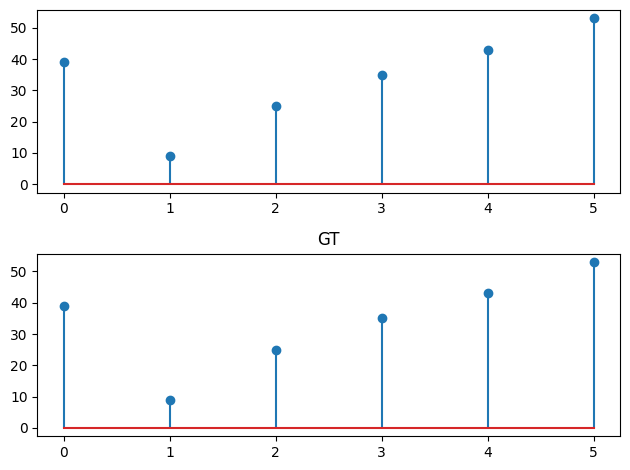

In [25]:
plt.subplot(2,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(2,1,2), plt.stem(tf.squeeze(y1n).numpy()), plt.title('GT')
plt.tight_layout()


In [26]:
tf.reduce_sum(tf.square(yhat)), tf.reduce_sum(tf.square(y1n)), 

(<tf.Tensor: shape=(), dtype=float32, numpy=8109.998046875>,
 <tf.Tensor: shape=(), dtype=float32, numpy=8110.0>)

        CHECK: LINEAR KERNEL PASS

In [27]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [28]:
x.shape

TensorShape([6])

In [29]:
# %% Quadratic kernel (m=2)
"""Quadratic kernel"""
# x = [0,0,0,1,0,0,0,0]
# filter init
# h = tf.constant([1, 2, 1])
h2 = tf.einsum('i,j->ij', h, h)
print(h2)
L = h.shape[0] #filter length
# n = tf.range(L) 
Npoint = x.shape[0]
# Npoint = len(x)
paddings = [
           [0, Npoint - L],  # Depth dimension
           [0, Npoint - L]
        ]
# x
Npoint, paddings
h_padded = tf.pad(h2, paddings, mode='CONSTANT', constant_values=0)
print(h_padded)
h_padded.shape


tf.Tensor(
[[1. 2.]
 [2. 4.]], shape=(2, 2), dtype=float32)
tf.Tensor(
[[1. 2. 0. 0. 0. 0.]
 [2. 4. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0.]], shape=(6, 6), dtype=float32)


TensorShape([6, 6])

In [30]:
# _ = tf.expand_dims(tf.expand_dims(h_padded, axis=0),axis=-1)
# _.shape
# from TFDWT3D.DWTIDWT2Dtfv1 import DWT2D, IDWT2D
# h_init = IDWT2D()(tf.cast(_, dtype=tf.float32))
# h_init


## creating h[n-k1,n-k2]
N = Npoint
n = tf.range(N)
# Create circular indices for all possible shifts
# row_indices = tf.math.mod(n[:, tf.newaxis] - tf.range(N), L)  # [N, N]
row_indices = tf.math.mod(n[:, tf.newaxis] - n, N)
rows_shifted = tf.gather(h_padded, row_indices, axis=0)         # [N, N, N]
rows_shifted
h_columns_shifted = tf.gather(rows_shifted, row_indices,   # [N, N, N]
                                axis=2, batch_dims=1)
h_columns_shifted, h_columns_shifted.shape

(<tf.Tensor: shape=(6, 6, 6), dtype=float32, numpy=
 array([[[1., 0., 0., 0., 0., 2.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [2., 0., 0., 0., 0., 4.]],
 
        [[4., 2., 0., 0., 0., 0.],
         [2., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0.],
         [0., 4., 2., 0., 0., 0.],
         [0., 2., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 4., 2., 0., 0.],
         [0., 0., 2., 1., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 

    mra

In [31]:
_ = tf.expand_dims(tf.cast(h_columns_shifted, dtype=tf.float32), axis=-1)
h_init = DWT2D(wave, clean=False)(_)
print(tf.squeeze(h_init))

tf.Tensor(
[[[ 0.49999997  0.          0.99999994  0.49999997  0.
   -0.99999994]
  [ 0.          0.          0.          0.          0.
    0.        ]
  [ 0.99999994  0.          1.9999999   0.99999994  0.
   -1.9999999 ]
  [ 0.49999997  0.          0.99999994  0.49999997  0.
   -0.99999994]
  [ 0.          0.          0.          0.          0.
    0.        ]
  [-0.99999994  0.         -1.9999999  -0.99999994  0.
    1.9999999 ]]

 [[ 4.4999995   0.          0.          1.4999999   0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.        ]
  [ 1.4999999   0.          0.          0.49999997  0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.        ]
  [ 0.          0.          0.          0.          0.
    0.        ]]

 [[ 1.9999999   0.99999994  0.         -1.9999999   0.99999994
    0.        ]
  [ 0.99999994  0.49999997  0.         -0.99999994  0.

In [32]:
DWT2D(wave, clean=False)(_[0:1,:,:,0:1])[0,:,:,0]

<tf.Tensor: shape=(6, 6), dtype=float32, numpy=
array([[ 0.49999997,  0.        ,  0.99999994,  0.49999997,  0.        ,
        -0.99999994],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [ 0.99999994,  0.        ,  1.9999999 ,  0.99999994,  0.        ,
        -1.9999999 ],
       [ 0.49999997,  0.        ,  0.99999994,  0.49999997,  0.        ,
        -0.99999994],
       [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ],
       [-0.99999994,  0.        , -1.9999999 , -0.99999994,  0.        ,
         1.9999999 ]], dtype=float32)>

In [33]:
_[0,:,:,0], h_init[0,:,:,0]

(<tf.Tensor: shape=(6, 6), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 2.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [2., 0., 0., 0., 0., 4.]], dtype=float32)>,
 <tf.Tensor: shape=(6, 6), dtype=float32, numpy=
 array([[ 0.49999997,  0.        ,  0.99999994,  0.49999997,  0.        ,
         -0.99999994],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [ 0.99999994,  0.        ,  1.9999999 ,  0.99999994,  0.        ,
         -1.9999999 ],
        [ 0.49999997,  0.        ,  0.99999994,  0.49999997,  0.        ,
         -0.99999994],
        [ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
          0.        ],
        [-0.99999994,  0.        , -1.9999999 , -0.99999994,  0.        ,
          1.9999999 ]], dtype=float32)>)

In [34]:
tf.expand_dims(h_init[:,0,0,:],axis=0)

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[0.49999997],
        [4.4999995 ],
        [1.9999999 ],
        [0.        ],
        [0.        ],
        [0.        ]]], dtype=float32)>

In [35]:
shape = tf.shape(h_init)
shape
_ = tf.reshape(h_init, [shape[0], shape[1], shape[2]* shape[3]])
_ = tf.transpose(_, perm=[1,0,2])
_ = DWT1D(wave, clean=False)(_)
_ = tf.transpose(_, perm=[1,0,2])
H = tf.reshape(_, [shape[0], shape[1], shape[2], shape[3]])
print(H.shape)
## earlier working code with squeeze
# H = tf.expand_dims(
#     tf.transpose(
#         DWT1D(wave, clean=False)(tf.transpose(tf.squeeze(h_init, axis=-1), perm=[1,0,2])),
#         perm=[1,0,2]),axis=-1)
H[:,:,:,0]

(6, 6, 6, 1)


<tf.Tensor: shape=(6, 6, 6), dtype=float32, numpy=
array([[[ 3.5355334e+00,  0.0000000e+00,  7.0710671e-01,  1.4142134e+00,
          0.0000000e+00, -7.0710671e-01],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00],
        [ 7.0710671e-01,  0.0000000e+00,  1.4142134e+00,  7.0710671e-01,
          0.0000000e+00, -1.4142134e+00],
        [ 1.4142134e+00,  0.0000000e+00,  7.0710671e-01,  7.0710671e-01,
          0.0000000e+00, -7.0710671e-01],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  0.0000000e+00,
          0.0000000e+00,  0.0000000e+00],
        [-7.0710671e-01,  0.0000000e+00, -1.4142134e+00, -7.0710671e-01,
          0.0000000e+00,  1.4142134e+00]],

       [[ 1.4142134e+00,  7.0710671e-01,  0.0000000e+00, -1.4142134e+00,
          7.0710671e-01,  0.0000000e+00],
        [ 7.0710671e-01,  3.5355334e+00,  0.0000000e+00, -7.0710671e-01,
          1.4142134e+00,  0.0000000e+00],
        [ 0.0000000e+00,  0

NSLI 2D and 3D Volterra system with LSI and QSI kernels     

---

Kishore Kumar Tarafdar, Date: 30-06-2025


In [36]:
# # import tensorflow as tf

# # # Example tensor h of shape (T, N1, N2)
# # h = tf.constant([
# #     [[1, 2], [3, 4]],
# #     [[5, 6], [7, 8]],
# #     [[9, 10], [11, 12]]
# # ], dtype=tf.float32)  # Shape: (3, 2, 2)

# # Define the operation (e.g., multiply by 2)
# # def operation(slice):
#     # return slice * 2  # Example operation

# # Apply the operation to h[:, n1, n2] for all n1 and n2
# for l1 in range(h_init.shape[1]):  # Loop over n1
#     for l2 in range(h_init.shape[2]):  # Loop over n2
#         # Extract the slice h[:, n1, n2]
#         slice = h_init[:, n1, n2 ,:]
#         # Apply the operation
#         modified_slice = tf.squeeze(DWT1D()(tf.expand_dims(h_init[:,l1,l2,:],axis=0)))
#         # print(modified_slice)
#         # Place the modified slice back into h
#         H = tf.tensor_scatter_nd_update(
#             h_init, 
#             [[i, l1, l2, j] for i in range(h_init.shape[0]) for j in range(h_init.shape[-1])], 
#             modified_slice)
# print(H)


In [37]:
# H[0,:,:,0]

In [38]:
# h_init[:, 0, 0 ,:].shape, tf.squeeze(DWT1D()(tf.expand_dims(h_init[:,l1,l2,:],axis=0)),axis=0).shape

In [39]:
x2 = tf.einsum('i,j->ij',x,x)
x2

<tf.Tensor: shape=(6, 6), dtype=float32, numpy=
array([[  1.,   7.,  11.,  13.,  17.,  19.],
       [  7.,  49.,  77.,  91., 119., 133.],
       [ 11.,  77., 121., 143., 187., 209.],
       [ 13.,  91., 143., 169., 221., 247.],
       [ 17., 119., 187., 221., 289., 323.],
       [ 19., 133., 209., 247., 323., 361.]], dtype=float32)>

In [40]:
α2 = DWT2D(wave, clean=False)(tf.expand_dims(tf.expand_dims(x2, axis=-1),axis=0))
α2.shape, tf.squeeze(α2)

(TensorShape([1, 6, 6, 1]),
 <tf.Tensor: shape=(6, 6), dtype=float32, numpy=
 array([[  32.       ,   96.       ,  144.       ,  -24.       ,
           -8.000002 ,   -7.999997 ],
        [  96.       ,  288.       ,  432.       ,  -72.       ,
          -23.999998 ,  -23.999983 ],
        [ 144.       ,  432.       ,  648.       , -108.       ,
          -35.999992 ,  -36.000008 ],
        [ -24.       ,  -72.       , -107.99999  ,   18.       ,
            6.0000024,    5.999996 ],
        [  -8.       ,  -24.000015 ,  -35.999985 ,    6.000004 ,
            2.0000076,    2.000002 ],
        [  -7.9999924,  -23.999985 ,  -36.00003  ,    5.999996 ,
            2.000002 ,    1.9999905]], dtype=float32)>)

---


In [41]:
H[0:1,:,:,:].shape

TensorShape([1, 6, 6, 1])

In [42]:
H.shape

TensorShape([6, 6, 6, 1])

In [43]:
DWT1D(wave, clean=False)(tf.expand_dims(tf.expand_dims(x, axis=-1),axis=0))

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[ 5.656854 ],
        [16.970562 ],
        [25.455843 ],
        [-4.2426405],
        [-1.4142132],
        [-1.4142137]]], dtype=float32)>

In [44]:
tf.expand_dims(
    tf.expand_dims(
        tf.stack(
            [tf.reduce_sum(H[k:k+1,:,:,:] * α2) for k in range(H.shape[0])]
            ), axis=-1),axis=0)

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[1132.785  ],
        [1308.1475 ],
        [3293.703  ],
        [1018.23364],
        [-424.26398],
        [-678.8224 ]]], dtype=float32)>

---

In [45]:
beta = tf.einsum('ijkc,bjkc->bic', H, α2)

## slower
# beta = tf.expand_dims(
#     tf.expand_dims(
#         tf.stack(
#             [tf.reduce_sum(H[k:k+1,:,:,:] * α2) for k in range(H.shape[0])]
#             ), axis=-1),axis=0)
beta

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[1132.7849 ],
        [1308.1473 ],
        [3293.7031 ],
        [1018.23364],
        [-424.264  ],
        [-678.8224 ]]], dtype=float32)>

In [46]:
y2 = IDWT1D(wave, clean=False)(beta)
y2

<tf.Tensor: shape=(1, 6, 1), dtype=float32, numpy=
array([[[1520.9998],
        [  81.    ],
        [ 624.9999],
        [1224.9998],
        [1848.9999],
        [2808.9998]]], dtype=float32)>

        natural ref

In [47]:
x2.shape, h2.shape, h_padded.shape

(TensorShape([6, 6]), TensorShape([2, 2]), TensorShape([6, 6]))

(6, 6) (6, 6, 6)


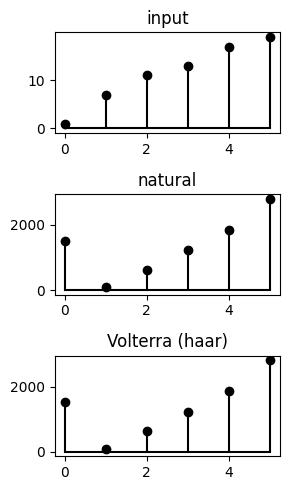

In [48]:
# ##natural ref slow
# import numpy as np
# def compute_q2(x2, h2):
#     N = x2.shape[0]
#     q2 = np.zeros(N).astype(float)
#     for n in range(N):
#         q2[n] = np.sum(h2 * x2[np.mod(n-np.arange(N), N),:][:, np.mod(n-np.arange(N), N)])
#     return q2

# q2 = compute_q2(x2.numpy(),h_padded.numpy())
# q2

##natural ref fast
print(x2.shape, h_columns_shifted.shape)
# y1n = 
q2 = tf.einsum('ijk,jk->i', h_columns_shifted, x2)
q2


plt.figure(figsize=(3,5))
plt.subplot(3,1,1), plt.stem(tf.squeeze(x).numpy(),'k', basefmt="k"), plt.title(f'input')
plt.subplot(3,1,2), plt.stem(tf.squeeze(q2).numpy(),'k', basefmt="k"), plt.title(f'natural')
plt.subplot(3,1,3), plt.stem(tf.squeeze(y2).numpy(),'k', basefmt="k"), plt.title(f'Volterra (haar)')
plt.tight_layout()